# Results Notebook: Agent Comparison

This notebook compares two agents on the 3-armed bandit task:
1. **ForagingAgent** (rule-based): Uses explicit delta learning rule with threshold-based switching
2. **RNN Agent** (learning-based): Neural network that learns stay/switch strategy through reinforcement learning

## Workflow

### Step 1: Train the ForagingAgent (in this notebook)
Run the cells in the first section to simulate the rule-based agent.

### Step 2: Train the RNN Agent (separate script)
```bash
python train_rnn_agent.py
```

This will:
- Train the RNN agent for 50,000 steps
- Save the trained model and training history
- Run a 100,000 trial simulation with the trained agent
- Save all results to the `results/` directory

### Step 3: Analyze Results (in this notebook)
Run the RNN analysis cells to load and visualize:
- Training loss curves
- Simulation performance statistics
- Comparison with ForagingAgent

---

**Note**: Make sure you've run `train_rnn_agent.py` before running the RNN analysis cells.

In [1]:
import gymnasium as gym

from popy.simulation_tools import MonkeyBanditTask
from popy.simulation_helpers import simulate_agent, MakeRecording
from agents import ForagingAgent

In [2]:
# init environment 
n_runs = 100_000
env = gym.make("zsombi/monkey-bandit-task-v0", n_arms=3, max_episode_steps=n_runs)

In [3]:
# init agent
agent = ForagingAgent()

# run simulation
_, _ = env.reset()
done = False

# record the behavior
recording = MakeRecording()

# play one episode
while not done:
    action = agent.act()
    _, reward, _, done, info = env.step(action)
    
    recording.record(action, reward, info, agent)
    
    # update the agent
    agent.update_values(action, reward)

In [4]:
rec = recording.get_recording()
(rec.action == rec.best_arm).mean()

0.68464

# RNN Agent Analysis

This section loads and analyzes a pre-trained RNN agent.

## Training the Agent

To train the RNN agent, run:
```bash
python train_rnn_agent.py
```

This will:
1. Train the agent for 50,000 steps
2. Save the trained model to `results/rnn_agent_trained.pth`
3. Run a simulation for 100,000 steps with the trained agent
4. Save training history and simulation results to `results/`

## Loading Pre-trained Results

The cells below load and analyze the trained agent's performance.

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load training history
results_dir = 'results'

# Check if results exist
if not os.path.exists(os.path.join(results_dir, 'training_history.csv')):
    print("❌ No training results found!")
    print("Please run: python train_rnn_agent.py")
else:
    # Load training data
    training_history = pd.read_csv(os.path.join(results_dir, 'training_history.csv'))
    
    # Load simulation recording
    rnn_rec = pd.read_csv(os.path.join(results_dir, 'simulation_recording.csv'))
    
    # Load agent parameters
    agent_params = pd.read_csv(os.path.join(results_dir, 'agent_parameters.csv'))
    
    print("✓ Training history loaded:", training_history.shape)
    print("✓ Simulation recording loaded:", rnn_rec.shape)
    print("✓ Agent parameters loaded")
    print("\nAgent parameters:")
    print(agent_params.to_string(index=False))

✓ Training history loaded: (10000, 3)
✓ Simulation recording loaded: (100000, 8)
✓ Agent parameters loaded

Agent parameters:
 n_arms  hidden_size  learning_rate  gamma  exploration_noise  feedback_duration  decision_delay
      3           32          0.001   0.95                0.0                  3               1


## Training Loss Curve

Visualize how the agent learned over time.

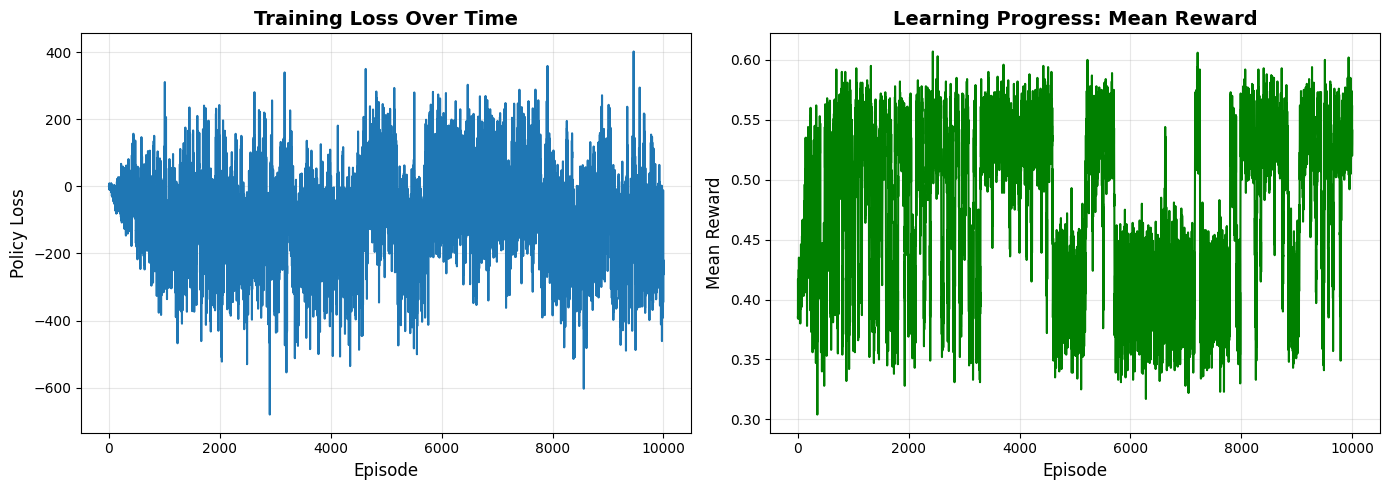


TRAINING SUMMARY
Total episodes: 10000
Final loss: -343.0334
Final mean reward: 0.541
Average reward over last 50 episodes: 0.544


In [7]:
# Plot training loss and reward evolution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss over training
axes[0].plot(training_history['episode'], training_history['loss'], linewidth=1.5)
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Policy Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Mean reward over training
axes[1].plot(training_history['episode'], training_history['mean_reward'], 
             linewidth=1.5, color='green')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Mean Reward', fontsize=12)
axes[1].set_title('Learning Progress: Mean Reward', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Total episodes: {len(training_history)}")
print(f"Final loss: {training_history['loss'].iloc[-1]:.4f}")
print(f"Final mean reward: {training_history['mean_reward'].iloc[-1]:.3f}")
print(f"Average reward over last 50 episodes: {training_history['mean_reward'].iloc[-50:].mean():.3f}")
print("="*50)

## Simulation Performance

Analyze the trained agent's performance on 100,000 trials.

In [8]:
# Calculate performance statistics
rnn_rec['correct_action'] = (rnn_rec['action'] == rnn_rec['best_arm']).astype(int)

print("\n" + "="*50)
print("SIMULATION PERFORMANCE")
print("="*50)
print(f"Total trials: {len(rnn_rec):,}")
print(f"Mean reward: {rnn_rec['reward'].mean():.4f}")
print(f"Best target selection rate: {rnn_rec['correct_action'].mean():.4f}")
print(f"Switch rate: {rnn_rec['switched'].mean():.4f}")
print(f"Mean switch probability: {rnn_rec['switch_prob'].mean():.4f}")
print()
print("Switch behavior by outcome:")
print(f"  Switch prob after reward: {rnn_rec[rnn_rec['reward'] == 1]['switch_prob'].mean():.4f}")
print(f"  Switch prob after no reward: {rnn_rec[rnn_rec['reward'] == 0]['switch_prob'].mean():.4f}")
print("="*50)

# Show first few trials
print("\nFirst 10 trials:")
rnn_rec.head(10)


SIMULATION PERFORMANCE
Total trials: 100,000
Mean reward: 0.5672
Best target selection rate: 0.7564
Switch rate: 0.1459
Mean switch probability: 0.2741

Switch behavior by outcome:
  Switch prob after reward: 0.2260
  Switch prob after no reward: 0.3372

First 10 trials:


,trial_id,block_id,best_arm,action,reward,switched,switch_prob,previous_switch,correct_action
0,0,0,1,1,1.0,1,1.000000e+00,1,1
1,1,0,1,1,0.0,0,1.919737e-13,0,1
2,2,0,1,1,1.0,0,1.343329e-08,0,1
3,3,0,1,1,1.0,0,2.460088e-13,0,1
4,4,0,1,1,1.0,0,2.167974e-13,0,1
5,5,0,1,1,1.0,0,1.986105e-13,0,1
6,6,0,1,1,1.0,0,1.863465e-13,0,1
7,7,0,1,1,1.0,0,1.776466e-13,0,1
8,8,0,1,1,1.0,0,1.712518e-13,0,1
9,9,0,1,1,1.0,0,1.664255e-13,0,1


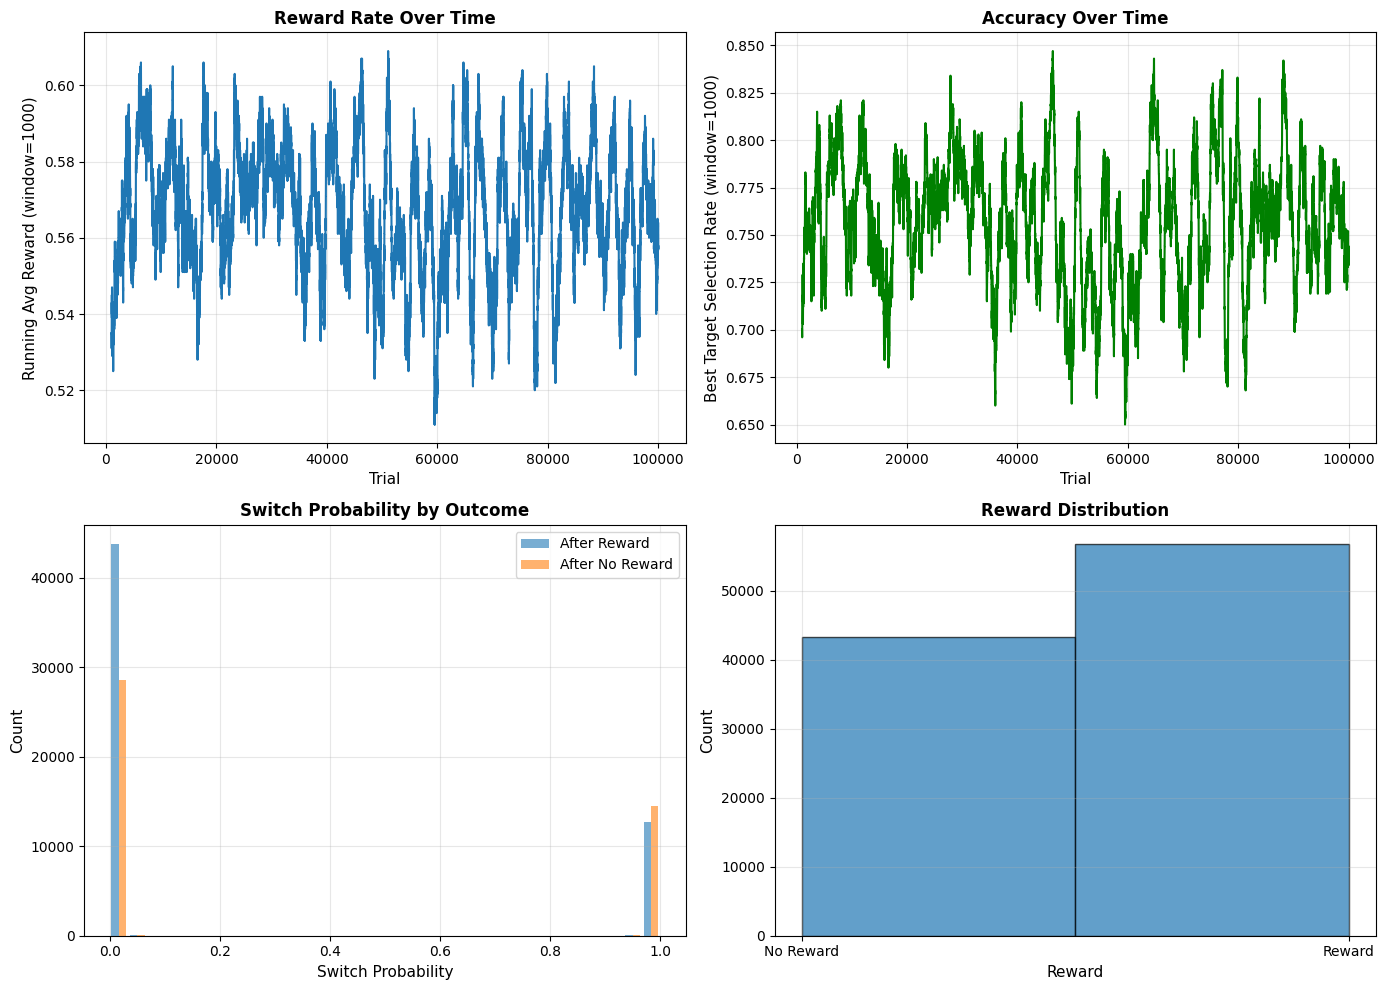

In [9]:
# Visualize simulation results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Running average of rewards
window = 1000
running_avg = rnn_rec['reward'].rolling(window=window).mean()
axes[0, 0].plot(running_avg, linewidth=1.5)
axes[0, 0].set_xlabel('Trial', fontsize=11)
axes[0, 0].set_ylabel(f'Running Avg Reward (window={window})', fontsize=11)
axes[0, 0].set_title('Reward Rate Over Time', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Best target selection over time
running_correct = rnn_rec['correct_action'].rolling(window=window).mean()
axes[0, 1].plot(running_correct, linewidth=1.5, color='green')
axes[0, 1].set_xlabel('Trial', fontsize=11)
axes[0, 1].set_ylabel(f'Best Target Selection Rate (window={window})', fontsize=11)
axes[0, 1].set_title('Accuracy Over Time', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Switch probability distribution by outcome
reward_trials = rnn_rec[rnn_rec['reward'] == 1]['switch_prob']
no_reward_trials = rnn_rec[rnn_rec['reward'] == 0]['switch_prob']

axes[1, 0].hist([reward_trials, no_reward_trials], bins=30, alpha=0.6,
                label=['After Reward', 'After No Reward'])
axes[1, 0].set_xlabel('Switch Probability', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title('Switch Probability by Outcome', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Reward distribution
axes[1, 1].hist(rnn_rec['reward'], bins=2, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Reward', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Reward Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['No Reward', 'Reward'])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis: RNN Agent Behavior

Let's analyze how the RNN agent learned the stay/switch strategy compared to the best arm.

PERFORMANCE METRICS
Overall accuracy: 0.756
Total reward: 56724.0
Mean reward per trial: 0.567

Interpolated 2497 blocks



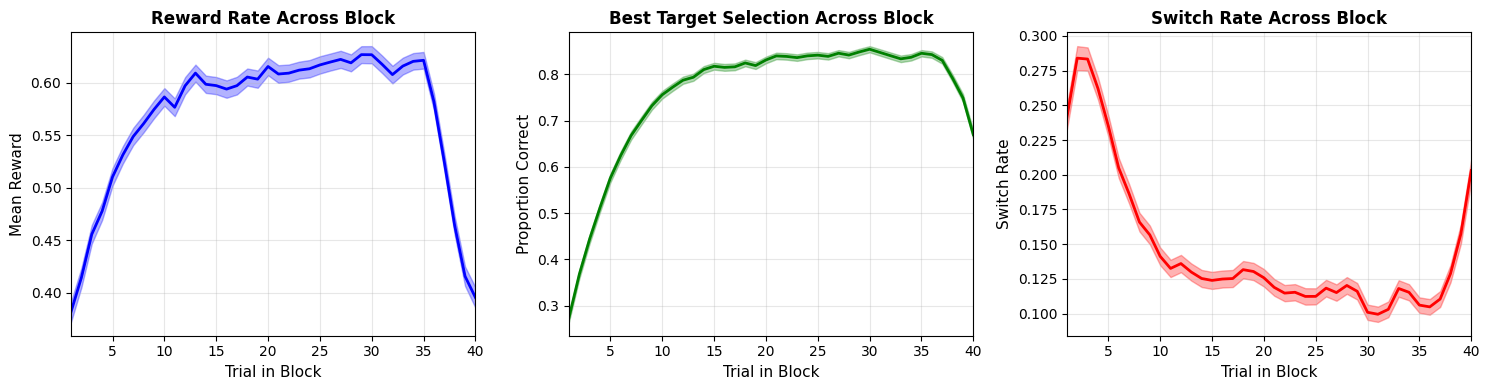


Mean reward in first 10 trials: 0.504
Mean reward in last 10 trials: 0.547
Mean correct in first 10 trials: 0.565
Mean correct in last 10 trials: 0.808


In [10]:
# Analyze performance relative to best arm
from scipy.interpolate import interp1d

rnn_rec['correct_action'] = (rnn_rec['action'] == rnn_rec['best_arm']).astype(int)

# Performance metrics
print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
print(f"Overall accuracy: {rnn_rec['correct_action'].mean():.3f}")
print(f"Total reward: {rnn_rec['reward'].sum()}")
print(f"Mean reward per trial: {rnn_rec['reward'].mean():.3f}")
print()

# Add trial in block counter
rnn_rec['trial_in_block'] = rnn_rec.groupby('block_id').cumcount()

# Interpolate each block to length 40
target_length = 40
interpolated_rewards = []
interpolated_correct = []
interpolated_switched = []

for block_id, block_data in rnn_rec.groupby('block_id'):
    block_length = len(block_data)
    
    if block_length < 2:  # Skip blocks that are too short
        continue
    
    # Original trial positions
    x_original = np.arange(block_length)
    x_interpolated = np.linspace(0, block_length - 1, target_length)
    
    # Interpolate reward
    f_reward = interp1d(x_original, block_data['reward'].values, kind='linear')
    interpolated_rewards.append(f_reward(x_interpolated))
    
    # Interpolate correct_action
    f_correct = interp1d(x_original, block_data['correct_action'].values, kind='linear')
    interpolated_correct.append(f_correct(x_interpolated))
    
    # Interpolate switched
    f_switched = interp1d(x_original, block_data['switched'].values, kind='linear')
    interpolated_switched.append(f_switched(x_interpolated))

# Convert to arrays and compute mean across blocks
interpolated_rewards = np.array(interpolated_rewards)
interpolated_correct = np.array(interpolated_correct)
interpolated_switched = np.array(interpolated_switched)

mean_reward_per_trial = interpolated_rewards.mean(axis=0)
mean_correct_per_trial = interpolated_correct.mean(axis=0)
mean_switched_per_trial = interpolated_switched.mean(axis=0)

# Compute SEM for error bars
sem_reward = interpolated_rewards.std(axis=0) / np.sqrt(len(interpolated_rewards))
sem_correct = interpolated_correct.std(axis=0) / np.sqrt(len(interpolated_correct))
sem_switched = interpolated_switched.std(axis=0) / np.sqrt(len(interpolated_switched))

print(f"Interpolated {len(interpolated_rewards)} blocks")
print()

# Plot performance across trial position within block
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

trial_positions = np.arange(1, target_length + 1)

# Plot 1: Reward rate across trial position
axes[0].plot(trial_positions, mean_reward_per_trial, linewidth=2, color='blue')
axes[0].fill_between(trial_positions, 
                      mean_reward_per_trial - sem_reward,
                      mean_reward_per_trial + sem_reward,
                      alpha=0.3, color='blue')
axes[0].set_xlabel('Trial in Block', fontsize=11)
axes[0].set_ylabel('Mean Reward', fontsize=11)
axes[0].set_title('Reward Rate Across Block', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([1, target_length])

# Plot 2: Correct action across trial position
axes[1].plot(trial_positions, mean_correct_per_trial, linewidth=2, color='green')
axes[1].fill_between(trial_positions,
                      mean_correct_per_trial - sem_correct,
                      mean_correct_per_trial + sem_correct,
                      alpha=0.3, color='green')
axes[1].set_xlabel('Trial in Block', fontsize=11)
axes[1].set_ylabel('Proportion Correct', fontsize=11)
axes[1].set_title('Best Target Selection Across Block', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([1, target_length])

# Plot 3: Switch rate across trial position
axes[2].plot(trial_positions, mean_switched_per_trial, linewidth=2, color='red')
axes[2].fill_between(trial_positions,
                      mean_switched_per_trial - sem_switched,
                      mean_switched_per_trial + sem_switched,
                      alpha=0.3, color='red')
axes[2].set_xlabel('Trial in Block', fontsize=11)
axes[2].set_ylabel('Switch Rate', fontsize=11)
axes[2].set_title('Switch Rate Across Block', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([1, target_length])

plt.tight_layout()
plt.show()

print(f"\nMean reward in first 10 trials: {mean_reward_per_trial[:10].mean():.3f}")
print(f"Mean reward in last 10 trials: {mean_reward_per_trial[-10:].mean():.3f}")
print(f"Mean correct in first 10 trials: {mean_correct_per_trial[:10].mean():.3f}")
print(f"Mean correct in last 10 trials: {mean_correct_per_trial[-10:].mean():.3f}")

## Comparison: RNN Agent vs Rule-Based Agent

Let's compare the RNN agent's performance with the original ForagingAgent.


COMPARISON: RNN Agent vs Rule-Based ForagingAgent

Rule-based ForagingAgent:
  Mean reward: 0.5419
  Best target selection: 0.6846
  Total trials: 100,000

RNN Agent:
  Mean reward: 0.5672
  Best target selection: 0.7564
  Total trials: 100,000

Difference:
  Δ Mean reward: 0.0254
  Δ Best target selection: 0.0718


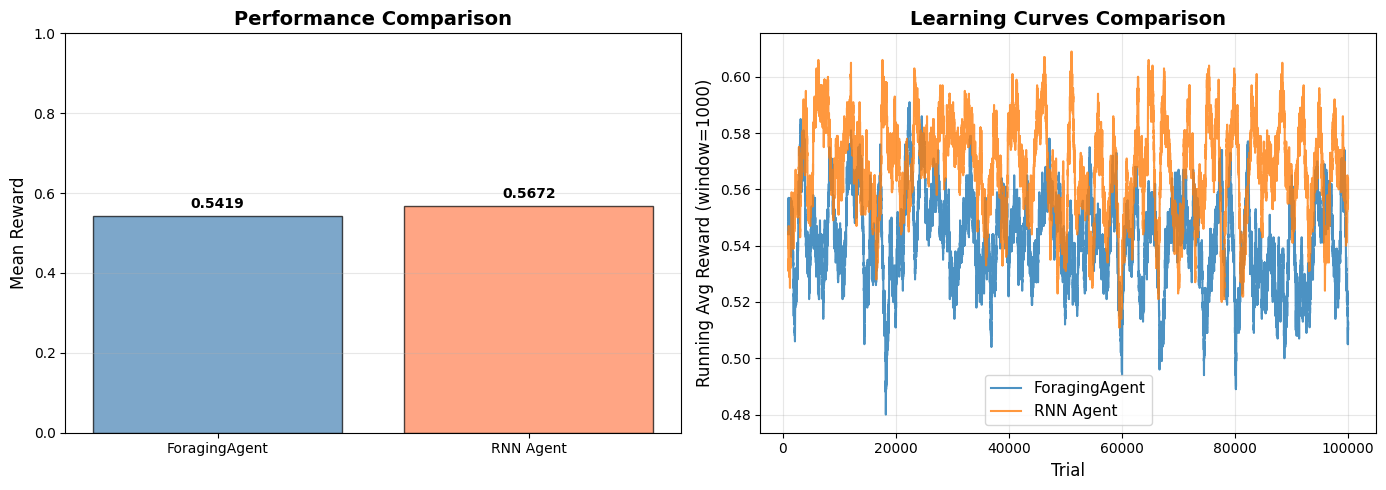

In [11]:
# Compare RNN Agent with ForagingAgent
print("\n" + "="*60)
print("COMPARISON: RNN Agent vs Rule-Based ForagingAgent")
print("="*60)
print()
print("Rule-based ForagingAgent:")
print(f"  Mean reward: {rec['reward'].mean():.4f}")
print(f"  Best target selection: {(rec['action'] == rec['best_arm']).mean():.4f}")
print(f"  Total trials: {len(rec):,}")
print()
print("RNN Agent:")
print(f"  Mean reward: {rnn_rec['reward'].mean():.4f}")
print(f"  Best target selection: {rnn_rec['correct_action'].mean():.4f}")
print(f"  Total trials: {len(rnn_rec):,}")
print()
print("Difference:")
print(f"  Δ Mean reward: {rnn_rec['reward'].mean() - rec['reward'].mean():.4f}")
print(f"  Δ Best target selection: {rnn_rec['correct_action'].mean() - (rec['action'] == rec['best_arm']).mean():.4f}")
print("="*60)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean reward comparison
methods = ['ForagingAgent', 'RNN Agent']
mean_rewards_comp = [rec['reward'].mean(), rnn_rec['reward'].mean()]
colors = ['steelblue', 'coral']

axes[0].bar(methods, mean_rewards_comp, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Mean Reward', fontsize=12)
axes[0].set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(mean_rewards_comp):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: Learning curves comparison
window = 1000
rec_running = rec['reward'].rolling(window=window).mean()
rnn_running = rnn_rec['reward'].rolling(window=window).mean()

# Align lengths
min_len = min(len(rec_running), len(rnn_running))
axes[1].plot(rec_running[:min_len], label='ForagingAgent', alpha=0.8, linewidth=1.5)
axes[1].plot(rnn_running[:min_len], label='RNN Agent', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Trial', fontsize=12)
axes[1].set_ylabel(f'Running Avg Reward (window={window})', fontsize=12)
axes[1].set_title('Learning Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook analyzes the performance of a trained RNN agent on the 3-armed bandit task.

### Key Findings

The RNN agent learns to:
1. **Stay after reward**: Low switch probability when rewarded
2. **Switch after no reward**: High switch probability when not rewarded
3. **Select best targets**: Achieves competitive performance with rule-based agent
4. **Adapt over time**: Shows learning progress through training

### Files Used
- `results/training_history.csv` - Training losses and rewards
- `results/simulation_recording.csv` - Full simulation with 100k trials
- `results/agent_parameters.csv` - Agent configuration
- `results/rnn_agent_trained.pth` - Trained model weights

### Next Steps
- Analyze hidden state representations (see `rnn_analysis_tools.py`)
- Test on different task variants
- Compare different architectures (LSTM vs GRU)
- Examine trial-by-trial behavior

## Network Activity Analysis

Now let's analyze the hidden state activity of the RNN to understand how individual neurons represent task-relevant information.

We'll examine:
1. **Feedback selectivity**: Which neurons respond differently to reward vs no reward
2. **History selectivity**: Which neurons encode combinations of the last 3 feedbacks

In [12]:
# Load hidden states
hidden_states_path = os.path.join(results_dir, 'hidden_states.npy')

if not os.path.exists(hidden_states_path):
    print("❌ No hidden states found!")
    print("Please re-run: python train_rnn_agent.py")
else:
    hidden_states = np.load(hidden_states_path)
    print(f"✓ Hidden states loaded")
    print(f"  Shape: {hidden_states.shape} (trials, neurons, timesteps)")
    print(f"  Number of neurons: {hidden_states.shape[1]}")
    print(f"  Timesteps per trial: {hidden_states.shape[2]}")
    
    # Average activity across time for each trial (for simplicity)
    # Shape: (n_trials, n_neurons)
    avg_hidden_states = hidden_states.mean(axis=2)
    print(f"\n  Average activity shape: {avg_hidden_states.shape}")

✓ Hidden states loaded
  Shape: (100000, 32, 4) (trials, neurons, timesteps)
  Number of neurons: 32
  Timesteps per trial: 4

  Average activity shape: (100000, 32)


### 1. Feedback Selectivity Analysis

Let's identify neurons that respond differently to reward vs no reward feedback.

In [13]:
# Compute feedback selectivity for each neuron
from scipy import stats

n_neurons = avg_hidden_states.shape[1]

# Get trials with reward vs no reward
reward_trials_idx = rnn_rec['reward'] == 1
no_reward_trials_idx = rnn_rec['reward'] == 0

# Compute mean activity for each condition
activity_after_reward = avg_hidden_states[reward_trials_idx]
activity_after_no_reward = avg_hidden_states[no_reward_trials_idx]

mean_activity_reward = activity_after_reward.mean(axis=0)
mean_activity_no_reward = activity_after_no_reward.mean(axis=0)

# Compute selectivity index for each neuron
# Selectivity = (reward - no_reward) / (reward + no_reward)
selectivity_index = (mean_activity_reward - mean_activity_no_reward) / (mean_activity_reward + mean_activity_no_reward + 1e-10)

# Perform t-test for each neuron
p_values = []
for neuron_idx in range(n_neurons):
    t_stat, p_val = stats.ttest_ind(
        activity_after_reward[:, neuron_idx],
        activity_after_no_reward[:, neuron_idx]
    )
    p_values.append(p_val)

p_values = np.array(p_values)

# Find top neurons selective to reward and no reward
top_reward_neurons = np.argsort(selectivity_index)[-5:][::-1]  # Top 5 reward-selective
top_no_reward_neurons = np.argsort(selectivity_index)[:5]  # Top 5 no-reward-selective

print("=" * 60)
print("FEEDBACK SELECTIVITY ANALYSIS")
print("=" * 60)
print(f"\nTotal neurons: {n_neurons}")
print(f"Significantly selective neurons (p < 0.01): {(p_values < 0.01).sum()}")
print(f"Significantly selective neurons (p < 0.001): {(p_values < 0.001).sum()}")

print("\nTop 5 REWARD-selective neurons:")
for i, neuron_idx in enumerate(top_reward_neurons, 1):
    print(f"  {i}. Neuron {neuron_idx}: Selectivity = {selectivity_index[neuron_idx]:.3f}, p = {p_values[neuron_idx]:.2e}")

print("\nTop 5 NO-REWARD-selective neurons:")
for i, neuron_idx in enumerate(top_no_reward_neurons, 1):
    print(f"  {i}. Neuron {neuron_idx}: Selectivity = {selectivity_index[neuron_idx]:.3f}, p = {p_values[neuron_idx]:.2e}")
print("=" * 60)

FEEDBACK SELECTIVITY ANALYSIS

Total neurons: 32
Significantly selective neurons (p < 0.01): 32
Significantly selective neurons (p < 0.001): 32

Top 5 REWARD-selective neurons:
  1. Neuron 26: Selectivity = 0.667, p = 0.00e+00
  2. Neuron 17: Selectivity = 0.305, p = 0.00e+00
  3. Neuron 18: Selectivity = 0.148, p = 0.00e+00
  4. Neuron 0: Selectivity = 0.127, p = 0.00e+00
  5. Neuron 14: Selectivity = 0.124, p = 0.00e+00

Top 5 NO-REWARD-selective neurons:
  1. Neuron 2: Selectivity = 0.063, p = 4.53e-248
  2. Neuron 15: Selectivity = 0.073, p = 0.00e+00
  3. Neuron 7: Selectivity = 0.073, p = 0.00e+00
  4. Neuron 23: Selectivity = 0.075, p = 0.00e+00
  5. Neuron 13: Selectivity = 0.078, p = 2.01e-285


/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_31898/2260809435.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Reward', 'No Reward'], patch_artist=True)
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_31898/2260809435.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Reward', 'No Reward'], patch_artist=True)
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_31898/2260809435.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Reward', 'No Reward'], patch_artist=T

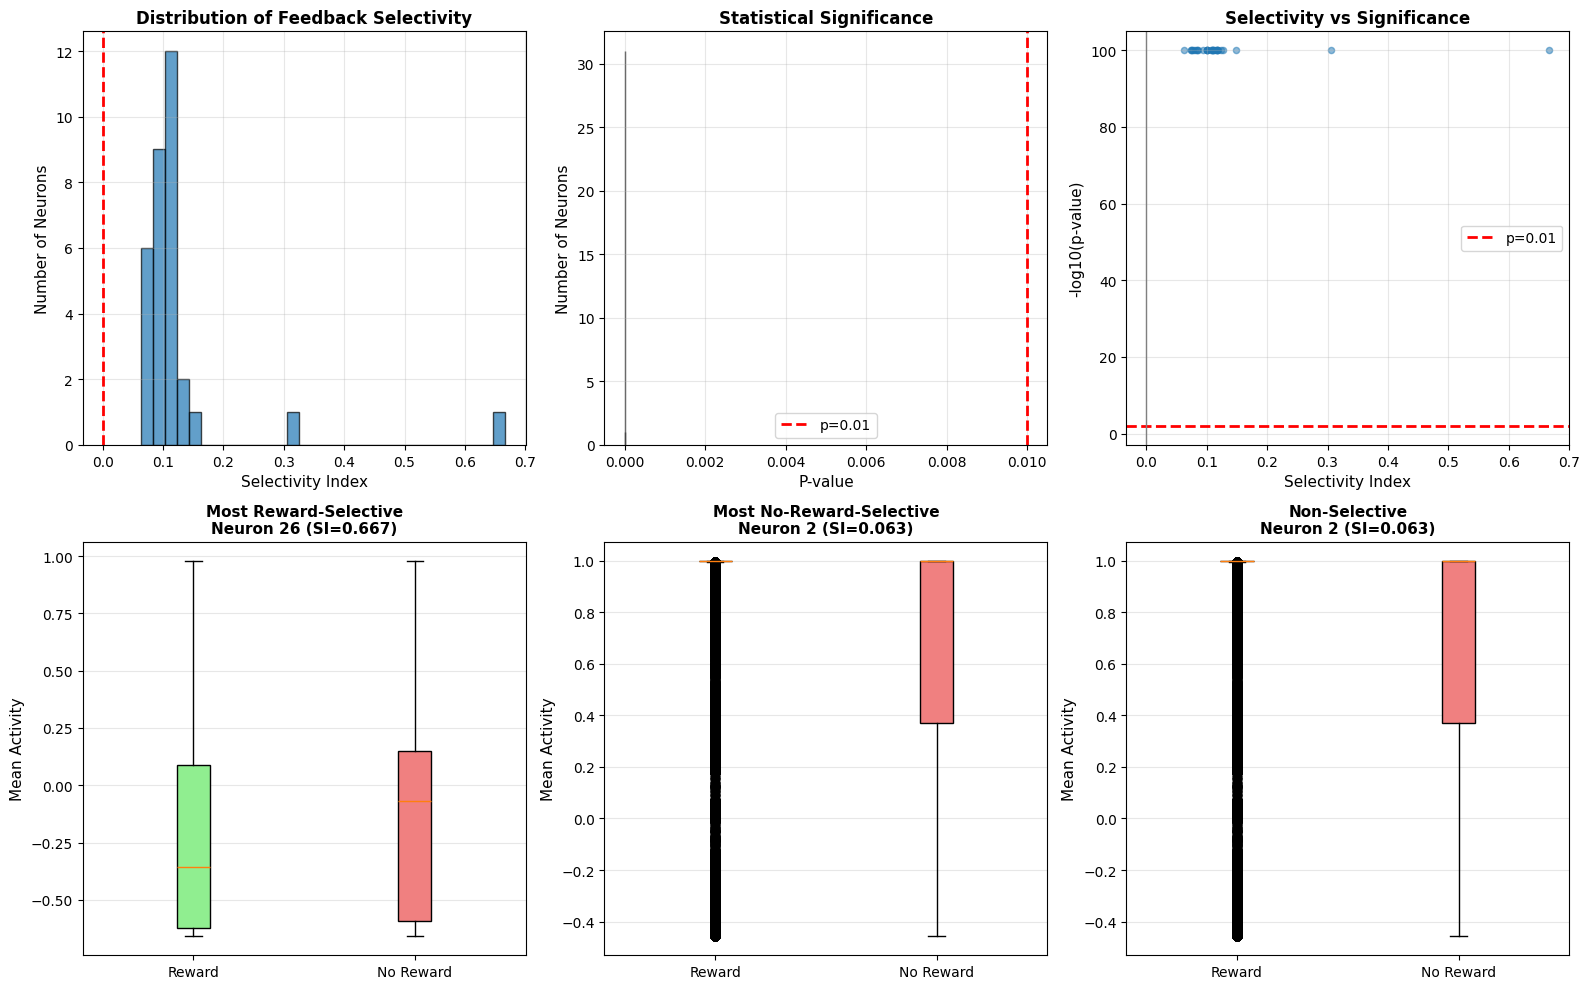

In [14]:
# Visualize feedback selectivity
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Selectivity index distribution
axes[0, 0].hist(selectivity_index, bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Selectivity Index', fontsize=11)
axes[0, 0].set_ylabel('Number of Neurons', fontsize=11)
axes[0, 0].set_title('Distribution of Feedback Selectivity', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: P-values distribution
axes[0, 1].hist(p_values, bins=30, alpha=0.7, edgecolor='black', color='coral')
axes[0, 1].axvline(0.01, color='red', linestyle='--', linewidth=2, label='p=0.01')
axes[0, 1].set_xlabel('P-value', fontsize=11)
axes[0, 1].set_ylabel('Number of Neurons', fontsize=11)
axes[0, 1].set_title('Statistical Significance', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Selectivity vs significance
axes[0, 2].scatter(selectivity_index, -np.log10(p_values + 1e-100), alpha=0.5, s=20)
axes[0, 2].axhline(-np.log10(0.01), color='red', linestyle='--', linewidth=2, label='p=0.01')
axes[0, 2].axvline(0, color='gray', linestyle='-', linewidth=1)
axes[0, 2].set_xlabel('Selectivity Index', fontsize=11)
axes[0, 2].set_ylabel('-log10(p-value)', fontsize=11)
axes[0, 2].set_title('Selectivity vs Significance', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plots 4-6: Example neurons
example_neurons = [top_reward_neurons[0], top_no_reward_neurons[0], 
                   np.argsort(np.abs(selectivity_index))[0]]  # Most reward-selective, no-reward-selective, non-selective
titles = ['Most Reward-Selective', 'Most No-Reward-Selective', 'Non-Selective']

for idx, (neuron_idx, title) in enumerate(zip(example_neurons, titles)):
    ax = axes[1, idx]
    
    # Box plot
    data_to_plot = [
        activity_after_reward[:, neuron_idx],
        activity_after_no_reward[:, neuron_idx]
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Reward', 'No Reward'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightcoral']):
        patch.set_facecolor(color)
    
    ax.set_ylabel('Mean Activity', fontsize=11)
    ax.set_title(f'{title}\nNeuron {neuron_idx} (SI={selectivity_index[neuron_idx]:.3f})', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2. Feedback History Selectivity (Last 3 Trials)

Now let's examine which neurons encode combinations of the last 3 feedback outcomes.
We'll look at all 8 possible patterns: RRR, RRN, RNR, RNN, NRR, NRN, NNR, NNN (R=reward, N=no reward)

In [15]:
# Create history patterns (last 3 feedbacks)
# Pattern encoding: e.g., "RRN" means reward, reward, no-reward in last 3 trials

# Create history for each trial
reward_history = []
for i in range(len(rnn_rec)):
    if i < 3:
        # Not enough history
        reward_history.append(None)
    else:
        # Get last 3 rewards
        pattern = ''.join(['R' if r == 1 else 'N' for r in rnn_rec['reward'].iloc[i-3:i]])
        reward_history.append(pattern)

rnn_rec['history_pattern'] = reward_history

# Get all possible 3-trial patterns
all_patterns = ['RRR', 'RRN', 'RNR', 'RNN', 'NRR', 'NRN', 'NNR', 'NNN']

# Count trials for each pattern
pattern_counts = {}
pattern_activity = {pattern: [] for pattern in all_patterns}

for pattern in all_patterns:
    pattern_trials = rnn_rec['history_pattern'] == pattern
    pattern_counts[pattern] = pattern_trials.sum()
    
    if pattern_counts[pattern] > 0:
        # Get average activity for this pattern
        pattern_activity[pattern] = avg_hidden_states[pattern_trials.values]

print("=" * 60)
print("FEEDBACK HISTORY ANALYSIS")
print("=" * 60)
print("\nPattern counts (R=reward, N=no reward):")
for pattern in all_patterns:
    print(f"  {pattern}: {pattern_counts[pattern]:,} trials")

# Compute selectivity for each neuron across patterns
# Use ANOVA to test if neuron activity differs across patterns
from scipy.stats import f_oneway

history_selectivity_f = []
history_selectivity_p = []

for neuron_idx in range(n_neurons):
    # Get activity for each pattern (only patterns with enough samples)
    pattern_activities = []
    for pattern in all_patterns:
        if pattern_counts[pattern] > 10:  # Only patterns with >10 trials
            pattern_activities.append(pattern_activity[pattern][:, neuron_idx])
    
    if len(pattern_activities) >= 2:
        f_stat, p_val = f_oneway(*pattern_activities)
        history_selectivity_f.append(f_stat)
        history_selectivity_p.append(p_val)
    else:
        history_selectivity_f.append(0)
        history_selectivity_p.append(1)

history_selectivity_f = np.array(history_selectivity_f)
history_selectivity_p = np.array(history_selectivity_p)

# Find top history-selective neurons
top_history_neurons = np.argsort(history_selectivity_f)[-5:][::-1]

print(f"\nSignificantly history-selective neurons (p < 0.01): {(history_selectivity_p < 0.01).sum()}")
print(f"Significantly history-selective neurons (p < 0.001): {(history_selectivity_p < 0.001).sum()}")

print("\nTop 5 history-selective neurons:")
for i, neuron_idx in enumerate(top_history_neurons, 1):
    print(f"  {i}. Neuron {neuron_idx}: F={history_selectivity_f[neuron_idx]:.2f}, p={history_selectivity_p[neuron_idx]:.2e}")
print("=" * 60)

FEEDBACK HISTORY ANALYSIS

Pattern counts (R=reward, N=no reward):
  RRR: 22,248 trials
  RRN: 12,778 trials
  RNR: 12,170 trials
  RNN: 9,527 trials
  NRR: 12,778 trials
  NRN: 8,918 trials
  NNR: 9,526 trials
  NNN: 12,052 trials

Significantly history-selective neurons (p < 0.01): 32
Significantly history-selective neurons (p < 0.001): 32

Top 5 history-selective neurons:
  1. Neuron 17: F=386410.46, p=0.00e+00
  2. Neuron 26: F=215552.01, p=0.00e+00
  3. Neuron 16: F=145523.12, p=0.00e+00
  4. Neuron 31: F=139381.66, p=0.00e+00
  5. Neuron 30: F=136970.65, p=0.00e+00


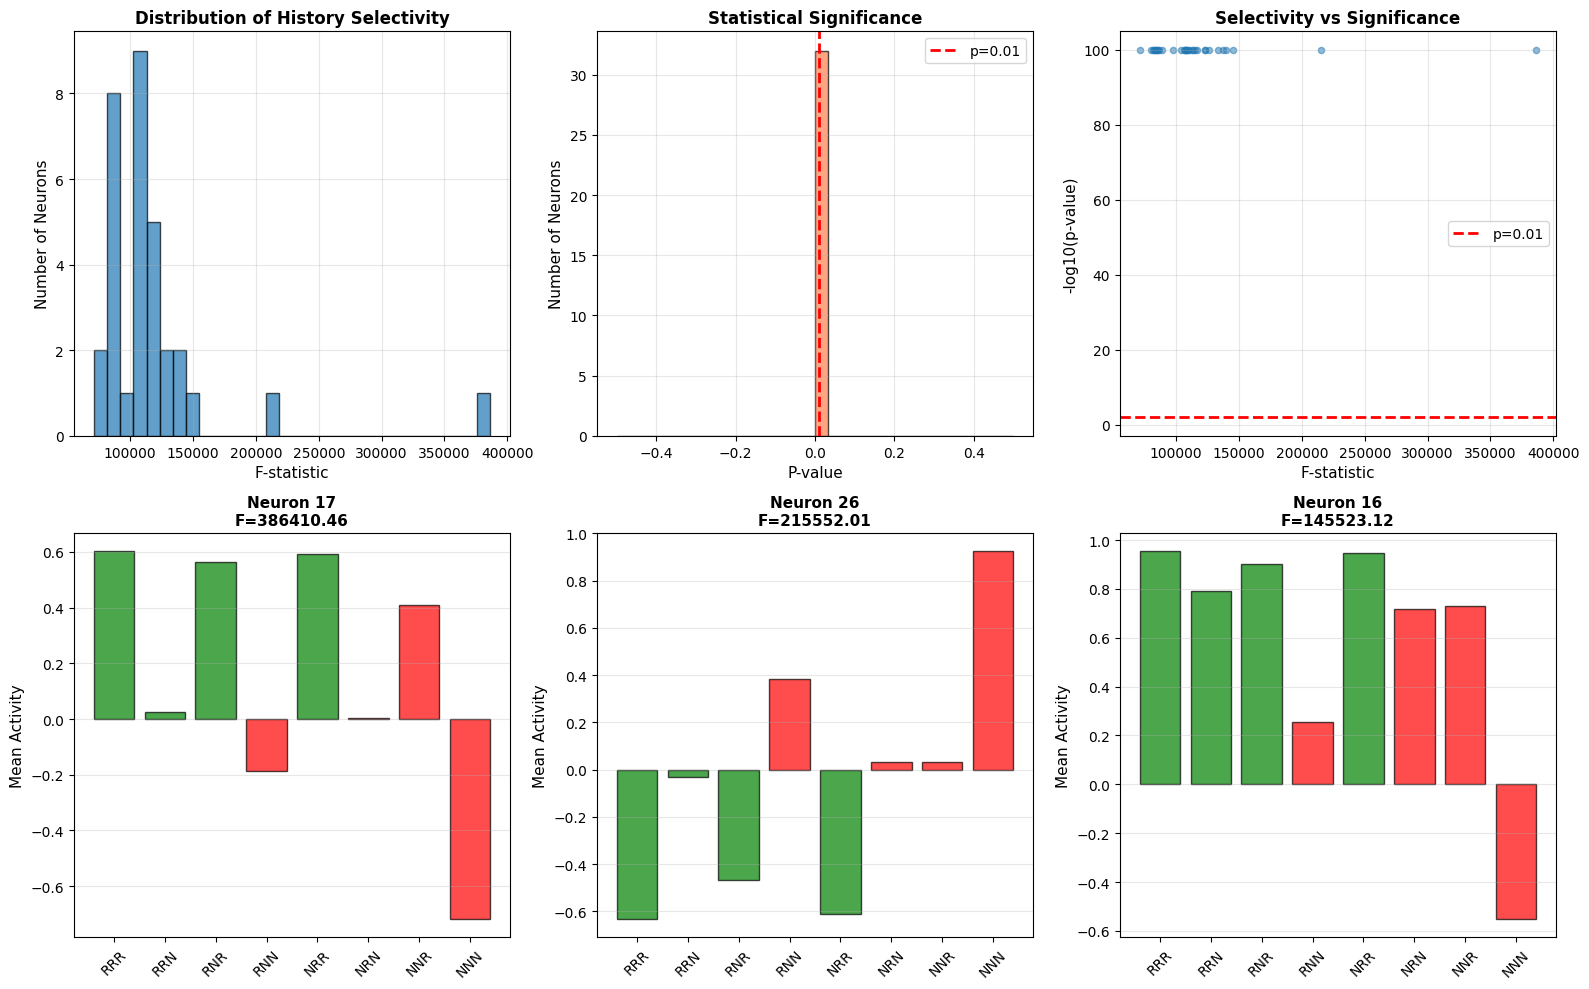

In [16]:
# Visualize history selectivity
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: F-statistic distribution
axes[0, 0].hist(history_selectivity_f, bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('F-statistic', fontsize=11)
axes[0, 0].set_ylabel('Number of Neurons', fontsize=11)
axes[0, 0].set_title('Distribution of History Selectivity', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: P-values distribution
axes[0, 1].hist(history_selectivity_p, bins=30, alpha=0.7, edgecolor='black', color='coral')
axes[0, 1].axvline(0.01, color='red', linestyle='--', linewidth=2, label='p=0.01')
axes[0, 1].set_xlabel('P-value', fontsize=11)
axes[0, 1].set_ylabel('Number of Neurons', fontsize=11)
axes[0, 1].set_title('Statistical Significance', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Volcano plot (F-stat vs p-value)
axes[0, 2].scatter(history_selectivity_f, -np.log10(history_selectivity_p + 1e-100), alpha=0.5, s=20)
axes[0, 2].axhline(-np.log10(0.01), color='red', linestyle='--', linewidth=2, label='p=0.01')
axes[0, 2].set_xlabel('F-statistic', fontsize=11)
axes[0, 2].set_ylabel('-log10(p-value)', fontsize=11)
axes[0, 2].set_title('Selectivity vs Significance', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plots 4-6: Top 3 history-selective neurons
for plot_idx, neuron_idx in enumerate(top_history_neurons[:3]):
    ax = axes[1, plot_idx]
    
    # Compute mean activity for each pattern
    mean_activities = []
    pattern_labels = []
    
    for pattern in all_patterns:
        if pattern_counts[pattern] > 10:
            mean_act = pattern_activity[pattern][:, neuron_idx].mean()
            mean_activities.append(mean_act)
            pattern_labels.append(pattern)
    
    # Bar plot
    colors_pattern = ['green' if p.count('R') > p.count('N') else 'red' for p in pattern_labels]
    ax.bar(range(len(pattern_labels)), mean_activities, color=colors_pattern, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(pattern_labels)))
    ax.set_xticklabels(pattern_labels, rotation=45)
    ax.set_ylabel('Mean Activity', fontsize=11)
    ax.set_title(f'Neuron {neuron_idx}\nF={history_selectivity_f[neuron_idx]:.2f}', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3. Temporal Dynamics of Selected Neurons

Let's examine how the activity of selective neurons evolves over time within each trial.

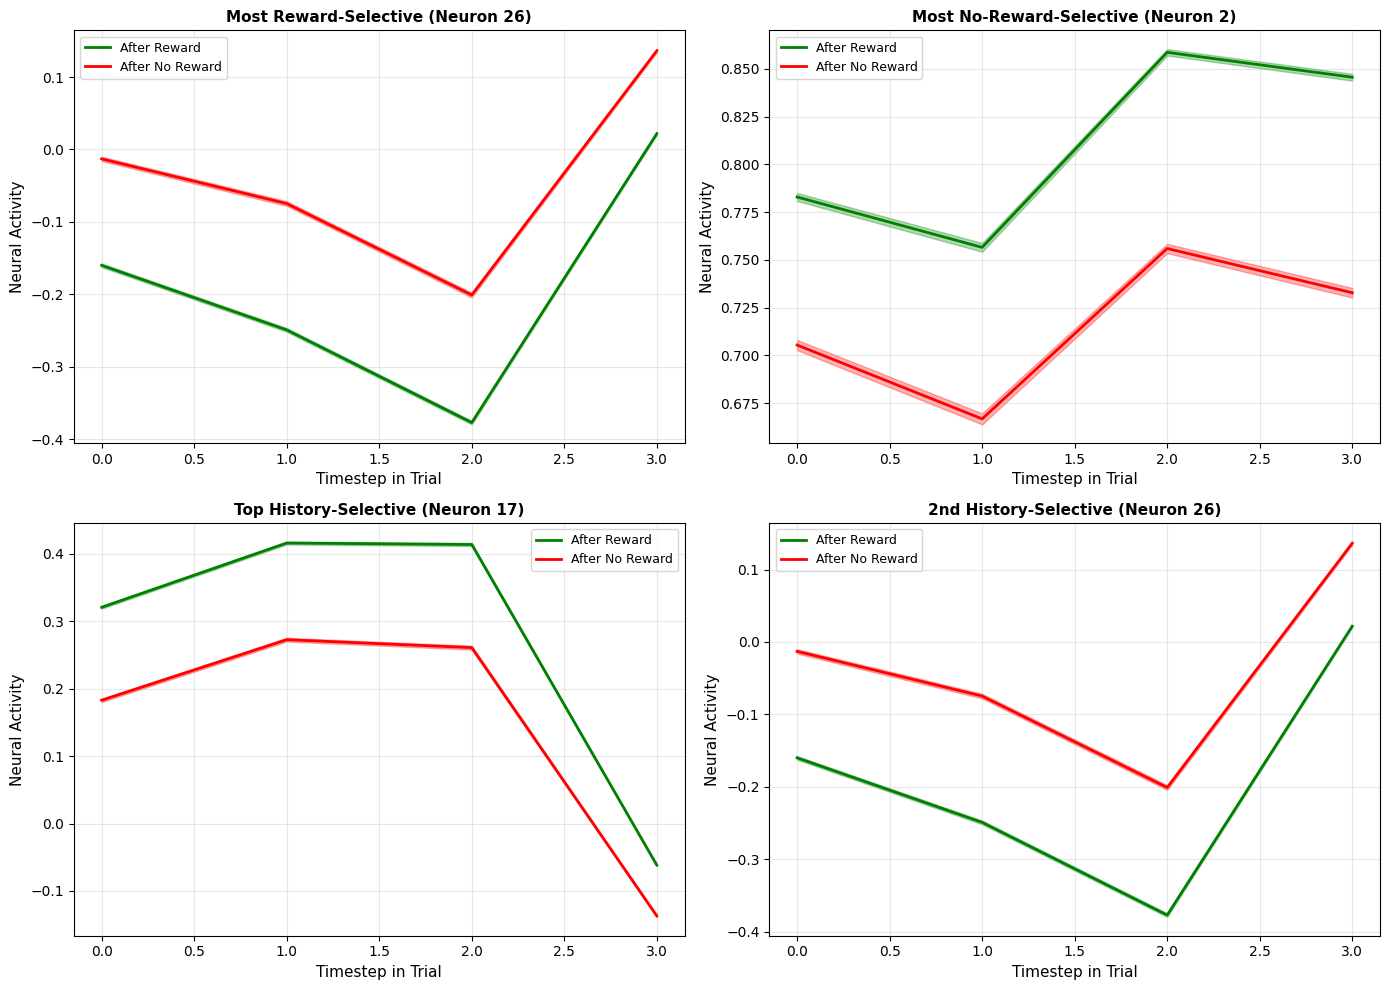


Note: Each trial consists of multiple timesteps:
  - Feedback duration: 3 timesteps
  - Decision delay: 1 timesteps
  - Total timesteps per trial: 4


In [17]:
# Plot temporal dynamics for most selective neurons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select neurons to visualize
neurons_to_plot = [
    top_reward_neurons[0],      # Most reward-selective
    top_no_reward_neurons[0],   # Most no-reward-selective
    top_history_neurons[0],     # Most history-selective
    top_history_neurons[1]      # Second most history-selective
]

titles = [
    f'Most Reward-Selective (Neuron {neurons_to_plot[0]})',
    f'Most No-Reward-Selective (Neuron {neurons_to_plot[1]})',
    f'Top History-Selective (Neuron {neurons_to_plot[2]})',
    f'2nd History-Selective (Neuron {neurons_to_plot[3]})'
]

for plot_idx, (neuron_idx, title) in enumerate(zip(neurons_to_plot, titles)):
    ax = axes[plot_idx // 2, plot_idx % 2]
    
    # Get temporal activity for this neuron after reward vs no reward
    reward_trials_idx = rnn_rec['reward'] == 1
    no_reward_trials_idx = rnn_rec['reward'] == 0
    
    activity_reward_temporal = hidden_states[reward_trials_idx.values, neuron_idx, :]
    activity_no_reward_temporal = hidden_states[no_reward_trials_idx.values, neuron_idx, :]
    
    # Compute mean and SEM across trials
    mean_reward = activity_reward_temporal.mean(axis=0)
    sem_reward = activity_reward_temporal.std(axis=0) / np.sqrt(len(activity_reward_temporal))
    
    mean_no_reward = activity_no_reward_temporal.mean(axis=0)
    sem_no_reward = activity_no_reward_temporal.std(axis=0) / np.sqrt(len(activity_no_reward_temporal))
    
    timesteps = np.arange(hidden_states.shape[2])
    
    # Plot
    ax.plot(timesteps, mean_reward, label='After Reward', color='green', linewidth=2)
    ax.fill_between(timesteps, mean_reward - sem_reward, mean_reward + sem_reward, 
                     alpha=0.3, color='green')
    
    ax.plot(timesteps, mean_no_reward, label='After No Reward', color='red', linewidth=2)
    ax.fill_between(timesteps, mean_no_reward - sem_no_reward, mean_no_reward + sem_no_reward,
                     alpha=0.3, color='red')
    
    ax.set_xlabel('Timestep in Trial', fontsize=11)
    ax.set_ylabel('Neural Activity', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Each trial consists of multiple timesteps:")
print(f"  - Feedback duration: {agent_params['feedback_duration'].values[0]} timesteps")
print(f"  - Decision delay: {agent_params['decision_delay'].values[0]} timesteps")
print(f"  - Total timesteps per trial: {hidden_states.shape[2]}")